In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.797 sec
Baseline,off


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('numpy')

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 52)

In [5]:
from hoda.hoda import BTTDA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler

n_blocks=16
bttda = BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(
            rank=None,
            max_iter=64,
            tol=1e-6,
            init ='mlsvd',
            shrinkage=(0,0),
            toeplitz=None,
            obj='diff',
            solver='lanczos',
            taper=False,
            keep_train_info=True,
            verbose=True,
    ),
    keep_train_info=True,
    verbose=True)                   

bttda.fit(X,y)

Fitting block 1/16...
Initializing factors...
Fitting discriminative tucker model of rank [1, 2] ...


  0%|          | 0/64 [00:00<?, ?it/s]


Fitting block 2/16...
Initializing factors...
Fitting discriminative tucker model of rank [6, 1] ...


  0%|          | 0/64 [00:00<?, ?it/s]


Fitting block 3/16...
Initializing factors...
Fitting discriminative tucker model of rank [3, 2] ...


...


Fitting block 15/16...
Initializing factors...
Fitting discriminative tucker model of rank [1, 1] ...


  0%|          | 0/64 [00:00<?, ?it/s]


Fitting block 16/16...
Initializing factors...
Fitting discriminative tucker model of rank [1, 2] ...


  0%|          | 0/64 [00:00<?, ?it/s]

BTTDA(hoda_params={'init': 'mlsvd', 'keep_train_info': True, 'max_iter': 64,
                   'obj': 'diff', 'rank': None, 'shrinkage': (0, 0),
                   'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                   'tol': 1e-06, 'verbose': True},
      keep_train_info=True, n_blocks=16, verbose=True)

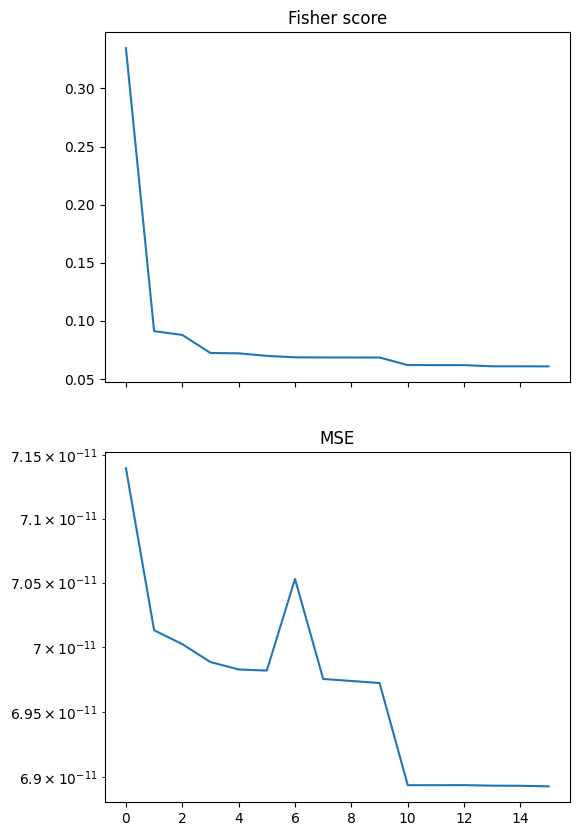

In [6]:
fig, axs = plt.subplots(2,1, sharex=True, figsize=(6,10))

axs[0].set_title('Fisher score')
axs[0].plot(bttda.train_info_["f_score"])


axs[1].set_title('MSE')
axs[1].semilogy(bttda.train_info_["mse"])

In [7]:
import cupy

"""
fig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))
for b in range(len(bttda.blocks_)):
    for k in range(2):
        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(scatter_w))
        sns.heatmap(scatter_w, cmap='BrBG',
                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    
        axs[b,k].set_aspect('equal')
"""

"\nfig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))\nfor b in range(len(bttda.blocks_)):\n    for k in range(2):\n        scatter_w = cupy.asnumpy(bttda.blocks_[b].scatter_w_[k])\n        vmax = np.max(np.abs(scatter_w))\n        sns.heatmap(scatter_w, cmap='BrBG',\n                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    \n        axs[b,k].set_aspect('equal')\n"

No projector specified for this dataset. Please consider the method self.add_proj.


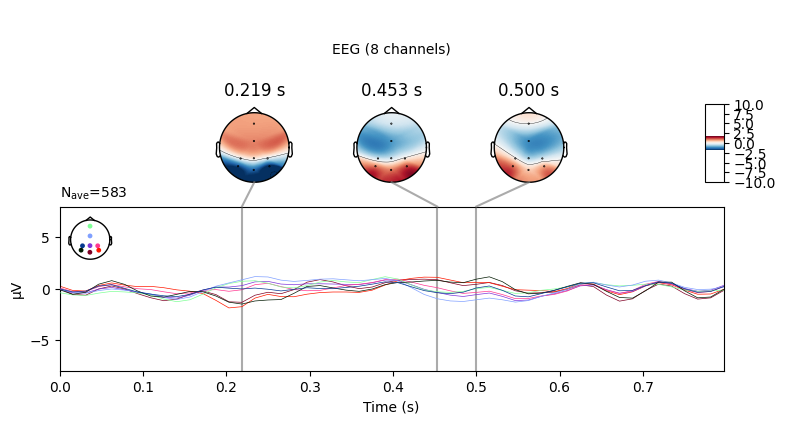

In [8]:
joint_args=dict(ts_args=dict(ylim=dict(eeg=[-8,8])))


target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
_ = contrast.plot_joint(**joint_args)

In [9]:
from mne import combine_evoked
""""
for b in range(len(bttda.blocks_)):
    epochs_rec = epochs.copy()
    epochs_rec._data = bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_rec.get_data()))
    
    target = epochs_rec['Target'].average()
    non_target = epochs_rec['NonTarget'].average()
    contrast = combine_evoked([target,non_target], weights=[1,-1])
    _ = contrast.plot_joint(**joint_args)
"""

'"\nfor b in range(len(bttda.blocks_)):\n    epochs_rec = epochs.copy()\n    epochs_rec._data = bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_rec.get_data()))\n    \n    target = epochs_rec[\'Target\'].average()\n    non_target = epochs_rec[\'NonTarget\'].average()\n    contrast = combine_evoked([target,non_target], weights=[1,-1])\n    _ = contrast.plot_joint(**joint_args)\n'

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import scipy.stats
import pandas as pd
from statsmodels.multivariate.manova import MANOVA

p_values = []
for b in range(1, len(bttda.blocks_)+1):
    Xt = bttda.transform(X, n_blocks=b)
    if Xt[0].size == 1:
        r = scipy.stats.ttest_ind(Xt[y=='Target'],Xt[y=='NonTarget'])
        p = r.pvalue[0]
    else:
        manova = MANOVA(Xt, y=='Target')
        p = manova.mv_test().results['x0']['stat'].values[0, 4]
    p_values.append(p)
    print(p)

2.9114016717195266e-170
1.159214176238742e-170
8.530589700977553e-193
1.6400739301854507e-212
2.347392019577405e-235
8.636372879550292e-234
3.01617375364384e-242
2.378166267116611e-244
4.696902358632484e-246
2.2518934479399354e-244
1.503123631752133e-243
2.142185654432316e-244
3.3777801456573665e-243
1.8982403615119686e-242
1.2313979499797776e-242
4.7695890639577895e-242


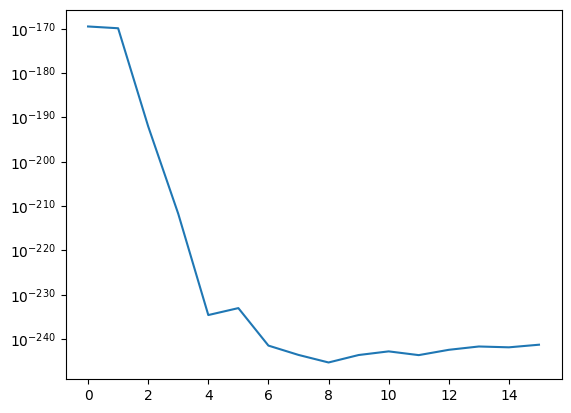

In [11]:
plt.semilogy(p_values)